# CC3092 – Laboratorio 7: ETTh1 Forecasting

**Dataset:** ETTh1 (Electricity Transformer Temperature – hourly, 2 years)  
**Variable objetivo:** `OT` (Oil Temperature)  
**Horizontes de predicción:** h = 24 h y h = 48 h  

> **NOTA:** Todo el código de las secciones marcadas debe implementarse con tensores PyTorch puros.  
> No se permite usar `nn.LSTM`, `nn.MultiheadAttention` ni ninguna capa de alto nivel que implemente  
> la arquitectura por usted. Puede usar `nn.Linear`, `nn.Parameter`, `torch.optim.Adam` y `loss.backward()` normalmente.

---
## Task 1 – Preprocesamiento y Análisis Exploratorio

### Task 1.1 – Descarga, normalización, split y ventanas deslizantes

In [1]:
# ── Imports globales ──────────────────────────────────────────────────────────
import urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Estructura del repo: datos descargados en data/ (ignorado en git), figuras en outputs/
DATA_DIR = Path("data");    DATA_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

In [2]:
# ── Descarga de ETTh1 ─────────────────────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/zhouhaoyi/"
    "ETDataset/main/ETT-small/ETTh1.csv"
)
CSV_PATH = DATA_DIR / "ETTh1.csv"
urllib.request.urlretrieve(URL, CSV_PATH)
print(f"{CSV_PATH} descargado.")

data\ETTh1.csv descargado.


In [3]:
# ── Carga con np.genfromtxt ───────────────────────────────────────────────────
# Columnas: date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT
# skip_header=1 descarta la fila de encabezados
data = np.genfromtxt(CSV_PATH, delimiter=",", skip_header=1)

OT  = data[:, -1].astype(np.float32)   # columna objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)   # 7 variables: 6 de carga + OT

print(f"Total de muestras: {len(OT)}")
print(f"ALL shape:         {ALL.shape}")
print(f"OT min/max:        {OT.min():.2f} / {OT.max():.2f}")

Total de muestras: 17420
ALL shape:         (17420, 7)
OT min/max:        -4.08 / 46.01


In [4]:
# ── 1.1 a) Normalización z-score de OT ───────────────────────────────────────
# OT_norm = (OT - mu) / sigma
# Guardamos mu y sigma para poder desnormalizar predicciones en Tasks 2/3/4.
mu    = float(OT.mean())         # media muestral
sigma = float(OT.std())          # desviación estándar muestral

OT_norm = (OT - mu) / sigma      # array numpy normalizado

print(f"mu    = {mu:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"OT_norm media ≈ {OT_norm.mean():.6f}  (debe ser ~0)")
print(f"OT_norm std  ≈ {OT_norm.std():.6f}  (debe ser ~1)")

mu    = 13.3247
sigma = 8.5667
OT_norm media ≈ -0.000000  (debe ser ~0)
OT_norm std  ≈ 1.000000  (debe ser ~1)


In [5]:
# ── 1.1 b) Split temporal contiguo (sin mezcla aleatoria) ────────────────────
# 60 % entrenamiento | 20 % validación | 20 % prueba
# El split es por bloques contiguos para respetar el orden temporal.
N       = len(OT_norm)
n_train = int(0.60 * N)
n_val   = int(0.20 * N)
n_test  = N - n_train - n_val   # resto exacto (no se pierde ningún dato)

# Convertimos a tensores PyTorch float32 para usarlos directamente con torch.abs, etc.
OT_train = torch.tensor(OT_norm[:n_train],              dtype=torch.float32)
OT_val   = torch.tensor(OT_norm[n_train:n_train+n_val], dtype=torch.float32)
OT_test  = torch.tensor(OT_norm[n_train+n_val:],        dtype=torch.float32)

print(f"Total:      {N}")
print(f"OT_train:   {len(OT_train):,}  ({len(OT_train)/N*100:.1f} %)")
print(f"OT_val:     {len(OT_val):,}  ({len(OT_val)/N*100:.1f} %)")
print(f"OT_test:    {len(OT_test):,}  ({len(OT_test)/N*100:.1f} %)")

# Verificación básica: los splits son contiguos, sin solape
assert len(OT_train) + len(OT_val) + len(OT_test) == N
assert OT_train[-1] != OT_val[0], "El último punto de train no debe ser el primero de val"
print("Split OK – ningún dato perdido, sin solape.")

Total:      17420
OT_train:   10,452  (60.0 %)
OT_val:     3,484  (20.0 %)
OT_test:    3,484  (20.0 %)
Split OK – ningún dato perdido, sin solape.


In [6]:
# ── 1.1 c) make_windows(series, L, H) ────────────────────────────────────────
# Construye ventanas deslizantes sobre una serie 1D (tensor PyTorch).
#
# Para cada posición t en [L-1, N-H-1]:
#   X(t) = (x_{t-L+1}, ..., x_t)   → ventana de contexto de longitud L
#   y(t) = x_{t+H}                 → valor objetivo a H pasos en el futuro
#
# Retorna:
#   X : tensor de forma (N_ventanas, L)
#   y : tensor de forma (N_ventanas,)

def make_windows(series: torch.Tensor, L: int, H: int):
    """
    Genera ventanas deslizantes.

    Args:
        series : tensor 1D de longitud T
        L      : longitud de la ventana de entrada (lookback)
        H      : horizonte de predicción

    Returns:
        X : (N, L) – ventanas de entrada
        y : (N,)   – valores objetivo
    """
    # Número de ventanas posibles
    # El primer índice objetivo es t=L-1+H, el último es T-1
    T = len(series)
    N_windows = T - L - H + 1   # equivalente a len(range(L-1, T-H))

    # Construcción vectorizada usando strides para eficiencia
    # xs[i] = series[i : i+L]  → ventana de entrada
    # ys[i] = series[i+L-1+H]  → objetivo
    xs = torch.stack([series[i:i+L]    for i in range(N_windows)])
    ys = torch.stack([series[i+L-1+H]  for i in range(N_windows)])
    return xs, ys


# Parámetros
L = 96   # longitud de ventana: 96 h = 4 días

# Horizonte h = 24 h
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

# Horizonte h = 48 h
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

print("Ventanas generadas:")
print(f"  h=24 → X_tr_24: {X_tr_24.shape}, y_tr_24: {y_tr_24.shape}")
print(f"  h=24 → X_vl_24: {X_vl_24.shape}, y_vl_24: {y_vl_24.shape}")
print(f"  h=24 → X_te_24: {X_te_24.shape}, y_te_24: {y_te_24.shape}")
print(f"  h=48 → X_tr_48: {X_tr_48.shape}, y_tr_48: {y_tr_48.shape}")
print(f"  h=48 → X_vl_48: {X_vl_48.shape}, y_vl_48: {y_vl_48.shape}")
print(f"  h=48 → X_te_48: {X_te_48.shape}, y_te_48: {y_te_48.shape}")

Ventanas generadas:
  h=24 → X_tr_24: torch.Size([10333, 96]), y_tr_24: torch.Size([10333])
  h=24 → X_vl_24: torch.Size([3365, 96]), y_vl_24: torch.Size([3365])
  h=24 → X_te_24: torch.Size([3365, 96]), y_te_24: torch.Size([3365])
  h=48 → X_tr_48: torch.Size([10309, 96]), y_tr_48: torch.Size([10309])
  h=48 → X_vl_48: torch.Size([3341, 96]), y_vl_48: torch.Size([3341])
  h=48 → X_te_48: torch.Size([3341, 96]), y_te_48: torch.Size([3341])


### Task 1.2 – Función de Autocorrelación (ACF) y correlograma

In [7]:
# ── 1.2 a) Implementación manual de la ACF ────────────────────────────────────
# La autocorrelación mide la correlación de una serie consigo misma desplazada k pasos.
#
# Fórmula:
#             (1/(N-k)) * Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄)
#  ρ(k) = ──────────────────────────────────────────────────────────
#                    (1/N) * Σ_{t=0}^{N-1} (x_t - x̄)²
#
# El denominador es la varianza muestral (corrección N, no N-1).

def acf_manual(series: np.ndarray, max_lag: int) -> np.ndarray:
    """
    Calcula la función de autocorrelación (ACF) para lags 0, 1, ..., max_lag.

    Args:
        series  : array numpy 1D
        max_lag : número máximo de lags a calcular

    Returns:
        rhos : array de longitud (max_lag + 1) con ρ(0), ρ(1), ..., ρ(max_lag)
    """
    x  = np.asarray(series, dtype=np.float64)
    xb = x.mean()                         # media muestral x̄
    N  = len(x)
    xc = x - xb                           # serie centrada

    # Denominador: varianza con factor 1/N (denominador fijo para todos los lags)
    var = np.dot(xc, xc) / N             # (1/N) * Σ(x_t - x̄)²

    rhos = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # Numerador: covarianza con lag k, factor 1/(N-k)
        # Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄)
        cov_k = np.dot(xc[k:], xc[:N-k]) / (N - k)
        rhos[k] = cov_k / var            # ρ(k) = cov(k) / var

    return rhos


# ── Cálculo sobre OT_train con max_lag=96 ────────────────────────────────────
MAX_LAG = 96
acf_vals = acf_manual(OT_train.numpy(), MAX_LAG)

print(f"ACF lag  0 (auto-correlación): {acf_vals[0]:.4f}  (siempre = 1)")
print(f"ACF lag 24 (1 día):            {acf_vals[24]:.4f}")
print(f"ACF lag 48 (2 días):           {acf_vals[48]:.4f}")
print(f"ACF lag 96 (4 días / L):       {acf_vals[96]:.4f}")

ACF lag  0 (auto-correlación): 1.0000  (siempre = 1)
ACF lag 24 (1 día):            0.9250
ACF lag 48 (2 días):           0.8763
ACF lag 96 (4 días / L):       0.8489


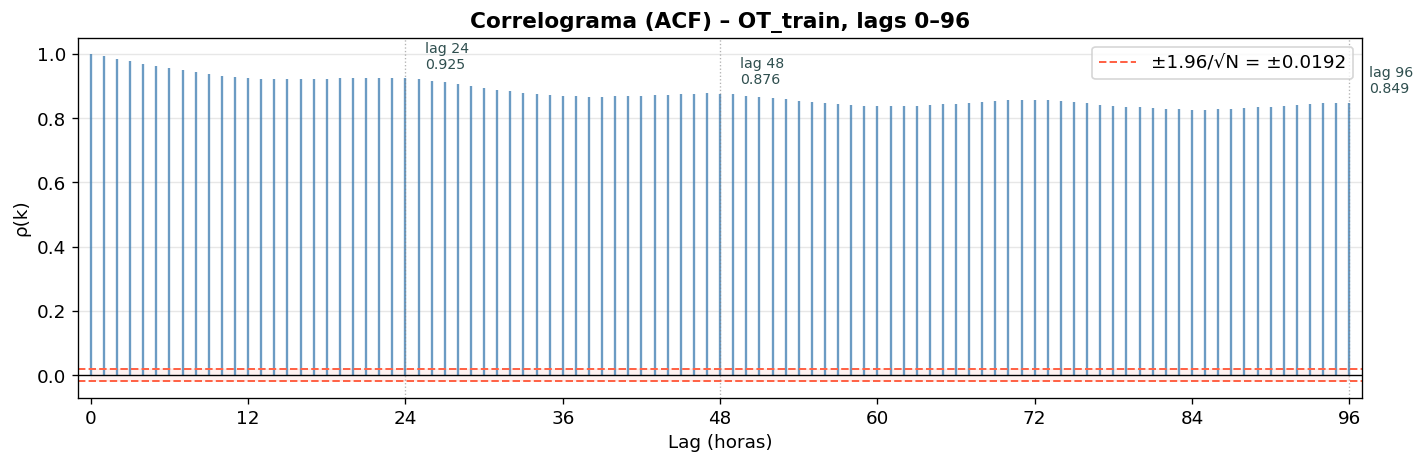

Figura guardada en outputs\acf_OT_train.png



Pico más alto  (excl. lag 0): lag  22  ρ = 0.9262
Segundo pico más alto:        lag  47  ρ = 0.8770


In [8]:
# ── Correlograma con líneas de confianza al 95 % (±1.96/√N) ──────────────────
N_train = len(OT_train)
conf    = 1.96 / np.sqrt(N_train)   # límite de confianza bilateral al 95 %

lags = np.arange(MAX_LAG + 1)

fig, ax = plt.subplots(figsize=(12, 4))

# Barras verticales (stem plot estilo correlograma)
ax.vlines(lags, 0, acf_vals, colors='steelblue', linewidth=1.4, alpha=0.8)
ax.axhline(0,    color='black', linewidth=0.8)

# Líneas de confianza al 95 %
ax.axhline( conf, color='tomato', linewidth=1.2, linestyle='--', label=f'±1.96/√N = ±{conf:.4f}')
ax.axhline(-conf, color='tomato', linewidth=1.2, linestyle='--')
ax.fill_between(lags, -conf, conf, color='tomato', alpha=0.08)

# Marcadores en lags clave
for lag_key in [24, 48, 96]:
    ax.axvline(lag_key, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.annotate(
        f'lag {lag_key}\n{acf_vals[lag_key]:.3f}',
        xy=(lag_key, acf_vals[lag_key]),
        xytext=(lag_key + 1.5, acf_vals[lag_key] + 0.03),
        fontsize=8.5,
        color='darkslategray'
    )

ax.set_title('Correlograma (ACF) – OT_train, lags 0–96', fontweight='bold')
ax.set_xlabel('Lag (horas)')
ax.set_ylabel('ρ(k)')
ax.set_xlim(-1, MAX_LAG + 1)
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'acf_OT_train.png', bbox_inches='tight')
plt.show()
print(f"Figura guardada en {OUT_DIR / 'acf_OT_train.png'}")

# Identificar segundo pico más alto (después de lag 0)
# El primer pico es siempre lag 0 (= 1.0); buscamos el siguiente máximo local.
from scipy.signal import find_peaks
peaks_idx, _ = find_peaks(acf_vals)
if len(peaks_idx) > 0:
    sorted_peaks = sorted(peaks_idx, key=lambda p: acf_vals[p], reverse=True)
    top_lag      = sorted_peaks[0]
    top_val      = acf_vals[top_lag]
    print(f"\nPico más alto  (excl. lag 0): lag {top_lag:3d}  ρ = {top_val:.4f}")
    if len(sorted_peaks) > 1:
        sec_lag = sorted_peaks[1]
        sec_val = acf_vals[sec_lag]
        print(f"Segundo pico más alto:        lag {sec_lag:3d}  ρ = {sec_val:.4f}")

In [9]:
# ── Verificación Task 1 (celdas exactas del enunciado) ────────────────────────
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El último valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto número de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


---
## Task 2 – LSTM Many-to-One 

### Task 2.1 – `LSTMForecaster` (celda LSTM procesada paso a paso)

In [10]:
# ── 2.1) LSTMForecaster: celda LSTM implementada paso a paso ──────────────────
# Ecuaciones de la celda LSTM en cada paso t:
#   z_t = x_t W_xᵀ + h_{t-1} W_hᵀ + b          → pre-activaciones de las 4 compuertas
#   i_t = σ(z_i)     compuerta de entrada
#   f_t = σ(z_f)     compuerta de olvido
#   g_t = tanh(z_g)  memoria candidata
#   o_t = σ(z_o)     compuerta de salida
#   c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t            → estado de celda (camino aditivo)
#   h_t = o_t ⊙ tanh(c_t)                      → estado oculto
# Many-to-one: solo h_L (último paso) se proyecta a la predicción.
#
# Normalización relativa al último valor (idea de NLinear / RevIN):
#   la ventana entra como x̃ = x - x_t  y el modelo predice el cambio Δ̂,
#   ŷ = x_t + Δ̂ = x_t + (h_L W_outᵀ + b_out)
# Motivo: la media de OT en validación (≈ -0.76) es muy distinta a la de
# entrenamiento (≈ +0.45). Con valores absolutos el LSTM se sesga hacia el nivel
# de train y pierde contra el naive; con valores relativos es invariante al nivel.
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        # Inicialización U(-1/√d_h, 1/√d_h), la misma que usa nn.LSTM
        k = 1.0 / d_h ** 0.5
        param = lambda *shape: nn.Parameter(torch.empty(*shape).uniform_(-k, k))
        self.Wx    = param(4 * d_h, d_in)   # entrada x_t → [i, f, g, o]
        self.Wh    = param(4 * d_h, d_h)    # recurrencia h_{t-1} → [i, f, g, o]
        self.b     = param(4 * d_h)         # sesgo de las 4 compuertas
        self.W_out = param(1, d_h)          # proyección h_L → escalar
        self.b_out = param(1)

    def forward(self, x):
        B, L = x.shape
        last = x[:, -1:]                             # x_t: último valor observado (B, 1)
        x = (x - last).unsqueeze(-1)                 # 1. ventana relativa, (B, L, 1)
        h = x.new_zeros(B, self.d_h)                 # 2. h_0 = 0
        c = x.new_zeros(B, self.d_h)                 #    c_0 = 0
        for t in range(L):                           # 3. recurrencia paso a paso
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b   # (B, 4·d_h)
            i, f, g, o = gates.chunk(4, dim=-1)      #    d_h columnas cada una
            i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
            g = torch.tanh(g)
            c = f * c + i * g                        #    c_t = f⊙c_{t-1} + i⊙g
            h = o * torch.tanh(c)                    #    h_t = o⊙tanh(c_t)
        delta = h @ self.W_out.T + self.b_out        # 4. Δ̂ = h_L W_outᵀ + b_out, (B, 1)
        return (delta + last).squeeze(-1)            # 5. ŷ = x_t + Δ̂, (B,)


# Chequeo rápido de forma
print(LSTMForecaster(d_in=1, d_h=32)(torch.randn(8, 96)).shape, "(esperado torch.Size([8]))")

torch.Size([8]) (esperado torch.Size([8]))


### Task 2.2 – Entrenamiento, métricas y curvas de pérdida

In [11]:
# ── 2.2) Loop de entrenamiento y predicción (reutilizable para el Transformer) ─
# Pérdida: MSE = (1/B) Σ (y - ŷ)²
#   - La serie está normalizada (media 0, std 1) y el error es aproximadamente
#     gaussiano → minimizar MSE equivale a máxima verosimilitud.
#   - Penaliza cuadráticamente los errores grandes: fallar un pico de temperatura
#     (riesgo de falla térmica) cuesta más que varios errores pequeños.
#   - Optimiza directamente el RMSE que se reporta como métrica.
# Las ventanas (X, y) son independientes entre sí, así que se barajan en cada época;
# el orden temporal ya está preservado DENTRO de cada ventana.

def train_model(model, X, y, epochs=20, batch_size=64, lr=1e-3):
    """Entrena con Adam + MSE. Retorna la pérdida promedio de entrenamiento por época."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(X)
    losses = []
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)                 # mezcla de ventanas (no de la serie)
        total = 0.0
        for s in range(0, n, batch_size):
            idx  = perm[s:s + batch_size]
            loss = F.mse_loss(model(X[idx]), y[idx])
            opt.zero_grad()
            loss.backward()                      # backprop (BPTT en el LSTM)
            opt.step()
            total += loss.item() * len(idx)
        losses.append(total / n)
        print(f"  época {ep:2d}/{epochs}  loss={losses[-1]:.5f}")
    return losses


@torch.no_grad()
def predict(model, X, batch_size=512):
    """Predicción por lotes sin gradientes. Retorna tensor (N,)."""
    model.eval()
    return torch.cat([model(X[s:s + batch_size]) for s in range(0, len(X), batch_size)])

In [12]:
# ── 2.2 a, b) Entrenamiento de dos LSTM: H = 24 y H = 48 ─────────────────────
# Misma configuración para ambos: d_h=32, Adam, 20 épocas, batch_size=64.
# Se fija la semilla antes de instanciar para que la inicialización sea reproducible.
print("== LSTM H=24 ==")
torch.manual_seed(42)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
loss_lstm_24 = train_model(lstm_24, X_tr_24, y_tr_24)

print("\n== LSTM H=48 ==")
torch.manual_seed(42)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
loss_lstm_48 = train_model(lstm_48, X_tr_48, y_tr_48)

== LSTM H=24 ==


  época  1/20  loss=0.14793


  época  2/20  loss=0.14257


  época  3/20  loss=0.14052


  época  4/20  loss=0.14028


...

  época 16/20  loss=0.23336


  época 17/20  loss=0.23297


  época 18/20  loss=0.22805


  época 19/20  loss=0.21990


  época 20/20  loss=0.22408


In [13]:
# ── 2.2 c) Métricas en validación: MAE, RMSE y ratio vs naive ────────────────
#   MAE  = (1/N) Σ |y - ŷ|
#   RMSE = √( (1/N) Σ (y - ŷ)² )
#   ratio = MAE_modelo / MAE_naive   (< 1 → el modelo supera al baseline)
# Baseline naive (persistencia): ŷ = último valor observado de la ventana, x_t.

def metrics(y, pred):
    err = y - pred
    return err.abs().mean().item(), err.pow(2).mean().sqrt().item()

pred_vl_24 = predict(lstm_24, X_vl_24)
pred_vl_48 = predict(lstm_48, X_vl_48)

mae_24,  rmse_24  = metrics(y_vl_24, pred_vl_24)
mae_48,  rmse_48  = metrics(y_vl_48, pred_vl_48)
nmae_24, nrmse_24 = metrics(y_vl_24, X_vl_24[:, -1])   # nmae_24 == naive_mae (Task 1)
nmae_48, nrmse_48 = metrics(y_vl_48, X_vl_48[:, -1])

rows = [
    ('LSTM',  24, mae_24,  rmse_24,  mae_24 / nmae_24),
    ('LSTM',  48, mae_48,  rmse_48,  mae_48 / nmae_48),
    ('Naive', 24, nmae_24, nrmse_24, 1.0),
    ('Naive', 48, nmae_48, nrmse_48, 1.0),
]

# Escala normalizada y en °C (desnormalizar un error solo requiere multiplicar por sigma)
print(f"{'Modelo':<7}{'H':>4} | {'MAE':>7}{'RMSE':>8} | {'MAE °C':>8}{'RMSE °C':>9} | {'Ratio':>6}")
print('-' * 58)
for name, h, mae, rmse, ratio in rows:
    print(f"{name:<7}{h:>4} | {mae:>7.4f}{rmse:>8.4f} | {mae*sigma:>8.3f}{rmse*sigma:>9.3f} | {ratio:>6.3f}")

Modelo    H |     MAE    RMSE |   MAE °C  RMSE °C |  Ratio
----------------------------------------------------------
LSTM     24 |  0.1918  0.2592 |    1.643    2.221 |  0.961
LSTM     48 |  0.2547  0.3243 |    2.182    2.778 |  0.978
Naive    24 |  0.1996  0.2672 |    1.710    2.289 |  1.000
Naive    48 |  0.2604  0.3359 |    2.231    2.878 |  1.000


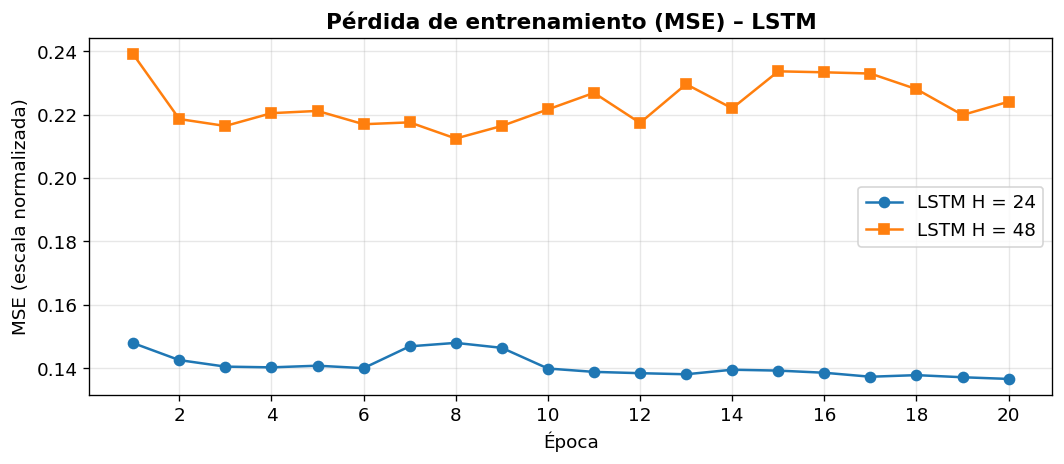

Figura guardada en outputs\lstm_loss_curves.png


In [14]:
# ── 2.2 d) Curvas de pérdida de entrenamiento (ambos horizontes) ─────────────
epochs = np.arange(1, len(loss_lstm_24) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, loss_lstm_24, marker='o', label='LSTM H = 24')
ax.plot(epochs, loss_lstm_48, marker='s', label='LSTM H = 48')
ax.set_title('Pérdida de entrenamiento (MSE) – LSTM', fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'lstm_loss_curves.png', bbox_inches='tight')
plt.show()
print(f"Figura guardada en {OUT_DIR / 'lstm_loss_curves.png'}")

In [15]:
# ── Verificación Task 2 (celda exacta del enunciado) ──────────────────────────
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f" LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
 LSTM H=24: MAE=0.1918, ratio=0.961


---
## Task 3 – Transformer Encoder con Self-Attention Temporal (PyTorch puro)

### Task 3.1 – Positional encoding y proyección de entrada

In [16]:
# ── 3.1 a) Positional encoding sinusoidal (Vaswani et al., 2017) ─────────────
#   PE(t, 2i)   = sin( t / 10000^{2i/d_model} )
#   PE(t, 2i+1) = cos( t / 10000^{2i/d_model} )
# Cada par de columnas (2i, 2i+1) es una sinusoide de frecuencia distinta: las
# dimensiones bajas oscilan rápido (posición fina) y las altas lento (posición gruesa).
# Se suma a la proyección de x_t porque la atención por sí sola es invariante al orden.

def make_pe(max_len, d_model):
    """Retorna tensor (max_len, d_model) con el positional encoding (no aprendible)."""
    t     = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)   # (L, 1)  posiciones
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)          # 2i = 0, 2, 4, ...
    angle = t / 10000 ** (two_i / d_model)                            # (L, ⌈d_model/2⌉)
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(angle)                                    # columnas pares
    pe[:, 1::2] = torch.cos(angle)[:, :d_model // 2]                  # impares (d_model impar)
    return pe


PE = make_pe(96, 32)
print(f"PE shape: {PE.shape}, requires_grad={PE.requires_grad}")
print(f"PE[0, :4] = {PE[0, :4].tolist()}  (sin 0 = 0, cos 0 = 1)")

PE shape: torch.Size([96, 32]), requires_grad=False
PE[0, :4] = [0.0, 1.0, 0.0, 1.0]  (sin 0 = 0, cos 0 = 1)


### Task 3.2 – Multi-head self-attention dentro de `TransformerForecaster`

In [17]:
# ── 3.2) TransformerForecaster: encoder de 1 capa con multi-head self-attention ─
# Bloque encoder (Vaswani et al., 2017), post-norm:
#   X₀ = x̃ W_in + b_in + PE                               (Task 3.1)
#   Q = X₀W_Q,  K = X₀W_K,  V = X₀W_V                     → se dividen en h cabezas de d_k
#   Attention(Q,K,V) = softmax(Q Kᵀ / √d_k) V              por cabeza
#   MHA(X₀) = Concat(head_1, …, head_h) W_O
#   X₁ = LayerNorm(X₀ + MHA(X₀))                          Add & Norm
#   X₂ = LayerNorm(X₁ + FFN(X₁)),  FFN(x) = ReLU(xW₁+b₁)W₂+b₂
#   ŷ  = x_t + X₂[:, 0, :] W_out + b_out                   posición 0 como token CLS
# Misma normalización relativa que el LSTM (x̃ = x - x_t, ŷ = x_t + Δ̂) para que la
# comparación LSTM vs Transformer (Task 4) use el mismo preprocesamiento.

class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L

        # 3.1 b) proyección escalar x_t ∈ ℝ → ℝ^{d_model}
        self.input_proj = nn.Linear(1, d_model)
        # PE fijo: buffer → se mueve con el modelo (.to/.cuda) pero NO es aprendible
        self.register_buffer("PE", make_pe(L, d_model))

        # Inicialización con varianza 1/fan_in (estilo Xavier/LeCun)
        W = lambda n_in, n_out: nn.Parameter(torch.randn(n_in, n_out) / n_in ** 0.5)

        # Proyecciones de atención (se aplican como x @ W)
        self.WQ = W(d_model, d_model)
        self.WK = W(d_model, d_model)
        self.WV = W(d_model, d_model)
        self.WO = W(d_model, d_model)

        # Feed-forward position-wise: d_model → d_ff → d_model
        self.W1 = W(d_model, d_ff)
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = W(d_ff, d_model)
        self.b2 = nn.Parameter(torch.zeros(d_model))

        # LayerNorm aprendible: γ = 1, β = 0 al inicio (identidad tras normalizar)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1  = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2  = nn.Parameter(torch.zeros(d_model))

        # Cabeza de regresión sobre el token CLS
        self.W_out = nn.Linear(d_model, 1)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        # LN(x) = γ ⊙ (x - μ) / √(σ² + ε) + β,  μ y σ² sobre la última dimensión
        mu  = x.mean(-1, keepdim=True)
        var = x.var(-1, keepdim=True, unbiased=False)
        return gamma * (x - mu) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        B, L, _ = x.shape
        # 1-2. Proyectar y separar cabezas: (B, L, d_model) → (B, n_heads, L, d_k)
        heads = lambda W: (x @ W).view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = heads(self.WQ), heads(self.WK), heads(self.WV)
        # 3. e_ts = q_tᵀ k_s / √d_k  → (B, n_heads, L, L)
        scores = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        # 4. α_ts = softmax_s(e_ts): cada fila suma 1
        attn_w = torch.softmax(scores, dim=-1)
        # 5. out_t = Σ_s α_ts v_s  → (B, n_heads, L, d_k)
        out = attn_w @ V
        # 6. Concatenar cabezas → (B, L, d_model) y mezclar con W_O
        out = out.transpose(1, 2).reshape(B, L, self.d_model) @ self.WO
        return out, attn_w

    def feed_forward(self, x):
        # FFN(x) = ReLU(x W₁ + b₁) W₂ + b₂
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        L = x.shape[1]
        last = x[:, -1]                                            # x_t: último valor (B,)
        x = x - last[:, None]                                      # ventana relativa x̃
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]         # 1. (B, L, d_model)
        att_out, attn_w = self.multi_head_attention(x)             # 2.
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)  # 3. Add & Norm
        ff_out = self.feed_forward(x)                              # 4.
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)   # 5. Add & Norm
        # 6. Posición 0 como CLS. Ojo: en la ventana, posición 0 = valor más antiguo (lag L)
        pred = self.W_out(x[:, 0, :]).squeeze(-1) + last           #    ŷ = x_t + Δ̂, (B,)
        return (pred, attn_w) if return_attn else pred

In [18]:
# ── Verificación Task 3 (celda exacta del enunciado: shapes y softmax) ────────
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f" attn_w shape: {_attn_test.shape}")
print(f" row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
 attn_w shape: torch.Size([4, 2, 96, 96])
 row sums OK: 1.0000 a 1.0000


### Task 3.3 – Entrenamiento del Transformer y mapas de atención

> *Pendiente.* Reutilizar `train_model`, `predict` y `metrics` de Task 2.2:
> `torch.manual_seed(42); trf_24 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96); loss_trf_24 = train_model(trf_24, X_tr_24, y_tr_24)`

---
## Task 4 – Comparación y Análisis Final

> *Celda pendiente – agregar código de Task 4 aquí.*